# 🌾 Smart Crop Dashboard — Activity Notebook
### AI Module Course · Session 3 · ESDU @ AUB

---

**What you will do in this notebook:**
1. Load and explore a 5-year agricultural dataset for Lebanon
2. Analyse crop performance under drought and normal conditions
3. Explore regional yield patterns
4. Investigate what factors most influence yield
5. Build a simple visual dashboard
6. Answer the **graded reflection questions** at the bottom

**If you prefer Excel / Tableau:** run the download cell in Step 0 to get the dataset as a `.xlsx` file, then complete your analysis there and come back to answer the graded questions at the end.

---
> 🕐 **Estimated time:** 30–45 minutes  
> 📋 **Graded deliverable:** Your written answers in the last section


In [ ]:
# ============================================================
# 👤 ENTER YOUR DETAILS BEFORE RUNNING ANYTHING ELSE
# ============================================================

STUDENT_NAME  = ""   # e.g. "John Doe"
STUDENT_EMAIL = ""   # e.g. "johndoe@gmail.com"  (use your Karianet login email)

# Quick check
assert STUDENT_NAME.strip(),  "❌ Please enter your name above before continuing."
assert STUDENT_EMAIL.strip(), "❌ Please enter your email above before continuing."
assert "@" in STUDENT_EMAIL,  "❌ Email doesn't look valid — check it."

print(f"✅ Student registered: {STUDENT_NAME} <{STUDENT_EMAIL}>")
print("You can now run the rest of the notebook.")


## ⚙️ Step 0 — Setup
*Run this cell first. It installs any missing libraries and sets up the environment.*

In [ ]:
# Install / import required libraries
import subprocess, sys
import matplotlib.pyplot as plt

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import pandas as pd
except ImportError:
    install("pandas"); import pandas as pd

try:
    import matplotlib.pyplot as plt
    import matplotlib
except ImportError:
    install("matplotlib"); import matplotlib.pyplot as plt; import matplotlib

try:
    import seaborn as sns
except ImportError:
    install("seaborn"); import seaborn as sns

import numpy as np

print("✅ All libraries ready!")
print(f"   pandas {pd.__version__} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")


✅ All libraries ready!
   pandas 2.2.2 · numpy 2.0.2 · matplotlib 3.10.0


---
## 📦 Step 1 — Load the Dataset

The dataset is generated below with a **fixed random seed** — every student gets identical data.

**Dataset overview:**
| Column | Description |
|--------|-------------|
| `year` | Harvest year (2019–2023) |
| `region` | Lebanese agricultural region |
| `crop` | Crop type |
| `yield_kg_ha` | Yield in kilograms per hectare |
| `rainfall_mm` | Annual rainfall in millimetres |
| `avg_temp_c` | Average growing-season temperature (°C) |
| `soil_moisture_pct` | Soil moisture percentage at harvest |
| `fertilizer_kg_ha` | Fertilizer applied (kg/ha) |
| `irrigated` | 1 = irrigated, 0 = rain-fed |
| `drought_year` | 1 = drought year (2021), 0 = normal |


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

crops   = ['Wheat', 'Olive', 'Potato', 'Tomato', 'Lentil', 'Grape', 'Sunflower']
regions = ['Bekaa Valley', 'South Lebanon', 'North Lebanon', 'Akkar', 'Mount Lebanon']
years   = [2019, 2020, 2021, 2022, 2023]

base_yield = {
    'Wheat': 3200, 'Olive': 2600, 'Potato': 17000,
    'Tomato': 32000, 'Lentil': 1100, 'Grape': 7500, 'Sunflower': 1800
}

region_mult = {
    'Bekaa Valley':  {'Wheat':1.25,'Olive':0.85,'Potato':1.30,'Tomato':1.20,'Lentil':1.10,'Grape':1.25,'Sunflower':1.15},
    'South Lebanon': {'Wheat':0.90,'Olive':1.30,'Potato':0.95,'Tomato':1.05,'Lentil':1.20,'Grape':0.95,'Sunflower':0.85},
    'North Lebanon': {'Wheat':1.05,'Olive':1.00,'Potato':1.10,'Tomato':1.00,'Lentil':1.05,'Grape':1.00,'Sunflower':1.10},
    'Akkar':         {'Wheat':1.15,'Olive':0.90,'Potato':1.20,'Tomato':1.10,'Lentil':0.95,'Grape':0.85,'Sunflower':1.20},
    'Mount Lebanon': {'Wheat':0.75,'Olive':1.20,'Potato':0.85,'Tomato':0.90,'Lentil':0.80,'Grape':1.30,'Sunflower':0.70},
}

year_factor = {2019: 1.02, 2020: 0.98, 2021: 0.68, 2022: 1.05, 2023: 1.08}
base_rain   = {'Bekaa Valley': 450, 'South Lebanon': 650, 'North Lebanon': 900, 'Akkar': 800, 'Mount Lebanon': 750}
year_rain   = {2019: 1.05, 2020: 0.95, 2021: 0.52, 2022: 1.10, 2023: 1.12}

rows = []
for region in regions:
    for crop in crops:
        for year in years:
            yf    = year_factor[year]
            noise = np.random.uniform(0.92, 1.08)
            y_val = round(base_yield[crop] * region_mult[region][crop] * yf * noise, 1)

            rain  = round(base_rain[region] * year_rain[year] * np.random.uniform(0.90, 1.10), 1)
            temp  = round(np.random.uniform(14, 22) + (np.random.uniform(1.5, 3.0) if year == 2021 else 0), 1)
            sm    = round(np.clip(rain / 1000 * 60 + np.random.uniform(-5, 5), 20, 75), 1)
            fert  = round(np.random.uniform(80, 180), 1)
            irr   = 1 if (region in ['Bekaa Valley','Akkar'] or crop in ['Tomato','Potato']) else int(np.random.choice([0,1], p=[0.4,0.6]))

            rows.append({'year': year, 'region': region, 'crop': crop,
                         'yield_kg_ha': y_val, 'rainfall_mm': rain,
                         'avg_temp_c': temp, 'soil_moisture_pct': sm,
                         'fertilizer_kg_ha': fert, 'irrigated': irr,
                         'drought_year': int(year == 2021)})

df = pd.DataFrame(rows)
print(f"✅ Dataset loaded — {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)


✅ Dataset loaded — 175 rows × 10 columns


,year,region,crop,yield_kg_ha,rainfall_mm,avg_temp_c,soil_moisture_pct,fertilizer_kg_ha,irrigated,drought_year
0,2019,Bekaa Valley,Wheat,3998.1,515.1,19.9,31.9,95.6,1,0
1,2020,Bekaa Valley,Wheat,3704.2,389.7,20.9,24.4,150.8,1,0
2,2021,Bekaa Valley,Wheat,2511.4,256.0,22.5,20.0,98.3,1,1
3,2022,Bekaa Valley,Wheat,4068.5,497.5,17.5,27.8,141.2,1,0
4,2023,Bekaa Valley,Wheat,4070.8,483.0,16.9,28.5,158.5,1,0
5,2019,Bekaa Valley,Olive,2145.9,473.8,18.7,23.9,140.8,1,0
6,2020,Bekaa Valley,Olive,2051.6,390.3,21.6,28.1,160.8,1,0
7,2021,Bekaa Valley,Olive,1455.8,215.2,21.6,20.0,129.5,1,1
8,2022,Bekaa Valley,Olive,2147.6,535.5,16.1,33.8,111.2,1,0
9,2023,Bekaa Valley,Olive,2394.5,508.7,15.5,35.2,157.5,1,0


---
## 🔍 Step 2 — Explore the Data

Before any analysis, always understand the shape and quality of your dataset.


In [ ]:
# Basic statistics for numeric columns
df.describe().round(1)


,year,yield_kg_ha,rainfall_mm,avg_temp_c,soil_moisture_pct,fertilizer_kg_ha,irrigated,drought_year
count,175.0,175.0,175.0,175.0,175.0,175.0,175.0,175.0
mean,2021.0,9424.7,676.2,18.2,40.7,127.3,0.9,0.2
std,1.4,11049.5,226.0,2.4,13.2,30.2,0.4,0.4
min,2019.0,590.9,215.2,14.2,20.0,80.6,0.0,0.0
25%,2020.0,1984.1,468.4,16.0,28.2,98.9,1.0,0.0
50%,2021.0,3519.7,724.8,18.2,42.5,126.2,1.0,0.0
75%,2022.0,14121.6,844.8,20.2,50.3,155.6,1.0,0.0
max,2023.0,42068.1,1106.0,24.0,70.1,179.7,1.0,1.0


In [ ]:
# Check for missing values — a clean dataset is the foundation of good analysis
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "  None ✅")

# Quick count of records per crop and region
print(f"\nCrops in dataset:   {sorted(df['crop'].unique())}")
print(f"Regions in dataset: {sorted(df['region'].unique())}")
print(f"Years covered:      {sorted(df['year'].unique())}")
print(f"Drought year(s):    {df[df.drought_year==1]['year'].unique()}")


Missing values per column:
  None ✅

Crops in dataset:   ['Grape', 'Lentil', 'Olive', 'Potato', 'Sunflower', 'Tomato', 'Wheat']
Regions in dataset: ['Akkar', 'Bekaa Valley', 'Mount Lebanon', 'North Lebanon', 'South Lebanon']
Years covered:      [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Drought year(s):    [2021]


In [ ]:
# Yield overview by crop (all years, all regions)
crop_summary = df.groupby('crop')['yield_kg_ha'].agg(['mean','min','max']).round(1)
crop_summary.columns = ['Average Yield', 'Min Yield', 'Max Yield']
crop_summary = crop_summary.sort_values('Average Yield', ascending=False)
print("📊 Average yield by crop (kg/ha across all years and regions):")
crop_summary


📊 Average yield by crop (kg/ha across all years and regions):


,Average Yield,Min Yield,Max Yield
crop,,,
Tomato,32119.5,20260.7,42068.1
Potato,17517.7,9145.4,25072.7
Grape,7771.4,4260.4,11159.9
Wheat,3129.7,1541.5,4070.8
Olive,2603.7,1455.8,3735.4
Sunflower,1734.6,886.8,2294.5
Lentil,1096.7,590.9,1474.5


> ⚠️ **Notice:** Crops like Tomato and Potato show much higher absolute yields than Wheat or Lentil. This is expected — different crops have very different yield scales. When comparing crops, always think about **what makes sense in context** (market value, water usage, cultural importance) not just the largest number.


---
## 🌵 Step 3 — Drought Resilience Analysis

**2021 was a severe drought year** — rainfall dropped to roughly half of normal levels.

Your first research question: **Which crop held up best under drought conditions?**

A crop that maintains a higher percentage of its normal yield during drought is more *resilient* — valuable knowledge for food security planning.


In [ ]:
# Calculate average yield in drought vs non-drought years
drought_df = df[df.drought_year == 1].groupby('crop')['yield_kg_ha'].mean()
normal_df  = df[df.drought_year == 0].groupby('crop')['yield_kg_ha'].mean()

resilience = pd.DataFrame({
    'Normal Year Avg (kg/ha)': normal_df.round(1),
    'Drought Year Avg (kg/ha)': drought_df.round(1),
})
resilience['Yield Retained (%)'] = (resilience['Drought Year Avg (kg/ha)'] / resilience['Normal Year Avg (kg/ha)'] * 100).round(1)
resilience = resilience.sort_values('Yield Retained (%)', ascending=False)

print("🌡️ Drought Resilience by Crop:")
print("(Higher % = more resilient)")
resilience


🌡️ Drought Resilience by Crop:
(Higher % = more resilient)


,Normal Year Avg (kg/ha),Drought Year Avg (kg/ha),Yield Retained (%)
crop,,,
Tomato,34207.3,23768.4,69.5
Potato,18768.0,12516.1,66.7
Sunflower,1864.4,1215.2,65.2
Lentil,1178.9,767.5,65.1
Olive,2804.2,1801.8,64.3
Grape,8373.6,5362.7,64.0
Wheat,3373.2,2155.5,63.9


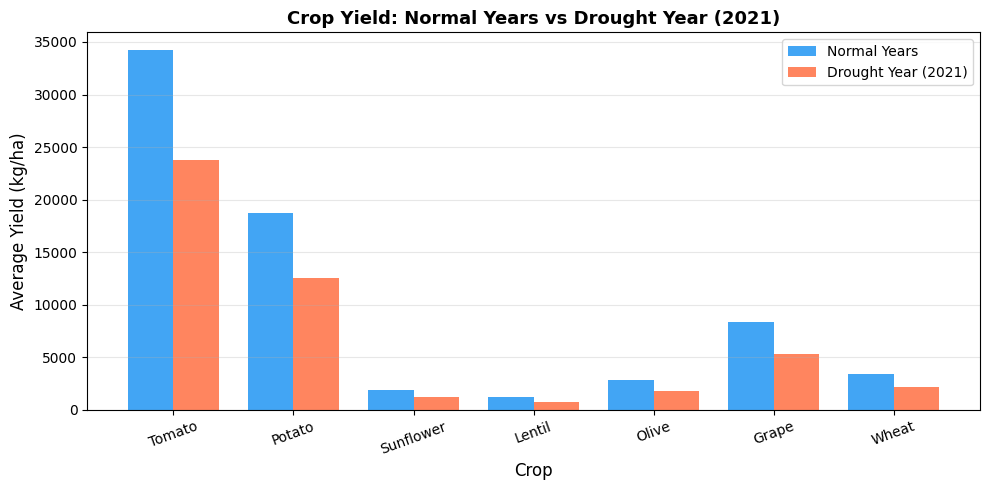


💡 The crop with the highest Yield Retained % is most drought-resilient.


In [ ]:
# Visualise drought impact
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(resilience))
width = 0.38

bars1 = ax.bar(x - width/2, resilience['Normal Year Avg (kg/ha)'], width,
               label='Normal Years', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, resilience['Drought Year Avg (kg/ha)'], width,
               label='Drought Year (2021)', color='#FF7043', alpha=0.85)

ax.set_xlabel('Crop', fontsize=12)
ax.set_ylabel('Average Yield (kg/ha)', fontsize=12)
ax.set_title('Crop Yield: Normal Years vs Drought Year (2021)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(resilience.index, rotation=20)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 The crop with the highest Yield Retained % is most drought-resilient.")


### ✏️ YOUR TURN — Drought Analysis

Answer the questions in the cell below. Replace the placeholder text with your own analysis.


In [ ]:
# ============================================================
# YOUR TURN: Drought Analysis
# ============================================================
# Use the resilience table above to answer these questions.
# You can also add additional code cells below to explore further.

# Q1: Which crop has the highest drought resilience (Yield Retained %)?
#     What do you think explains this?

your_answer_drought_q1 = """
[YOUR ANSWER HERE]

Example reasoning to guide you:
- Is this crop naturally drought-tolerant (deep roots, low water needs)?
- Was it more likely to be irrigated, reducing dependence on rainfall?
- Does it have a short growing season that avoids the driest months?
"""

# Q2: Which crop suffered the most from the drought?
#     What does this suggest for food security planning?

your_answer_drought_q2 = """
[YOUR ANSWER HERE]
"""

print("✅ Your drought analysis answers saved.")
print("Remember to complete the graded questions at the bottom of the notebook.")


---
## 🗺️ Step 4 — Regional Performance Analysis

Different regions in Lebanon have very different soil types, elevation, rainfall patterns, and temperatures.

Your second research question: **Which region shows the strongest yield potential — and for which crops?**


In [ ]:
# Regional averages across all crops and non-drought years
regional_avg = df[df.drought_year == 0].groupby('region')['yield_kg_ha'].mean().sort_values(ascending=False).round(1)
print("📍 Average yield by region (excluding drought year):")
print(regional_avg.to_string())


📍 Average yield by region (excluding drought year):
region
Bekaa Valley     11499.1
Akkar            10532.3
North Lebanon     9978.9
South Lebanon     9736.0
Mount Lebanon     8660.5


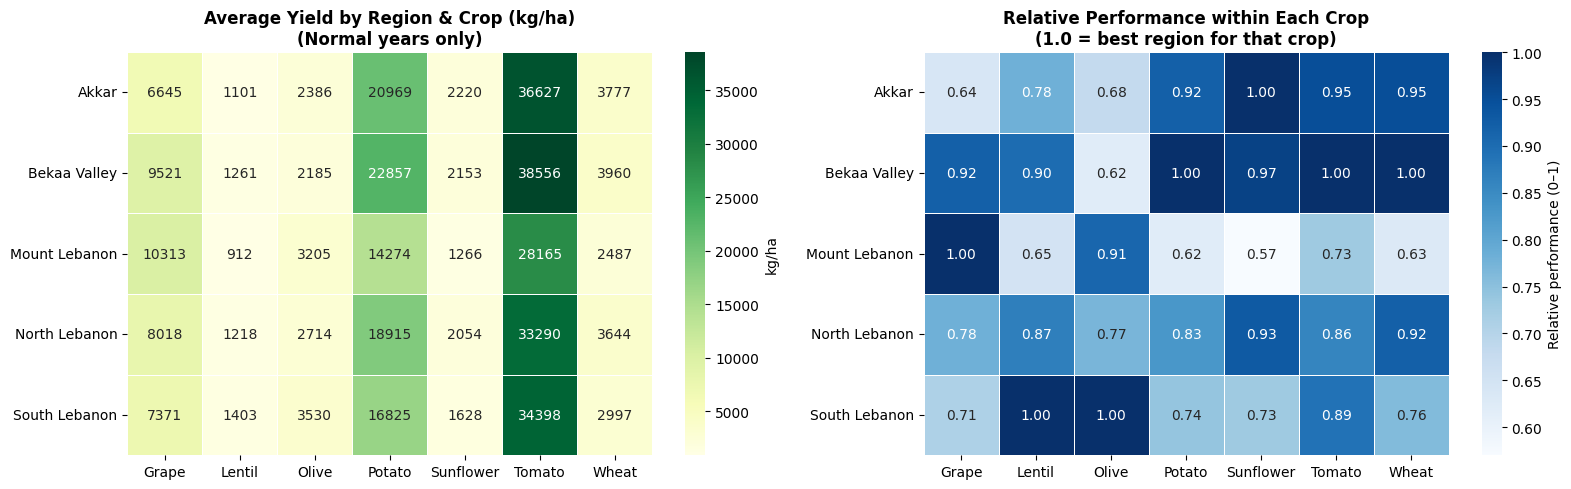


💡 The RIGHT heatmap is more useful for comparison — it shows which region performs
   best for each crop RELATIVE to other regions, independent of scale differences.


In [ ]:
# Heatmap: which crop performs best in which region?
pivot = df[df.drought_year == 0].groupby(['region','crop'])['yield_kg_ha'].mean().unstack()

# Normalise within each crop column (0-1) so we can compare across different yield scales
pivot_norm = pivot.div(pivot.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw yields
sns.heatmap(pivot.round(0), annot=True, fmt='.0f', cmap='YlGn',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'kg/ha'})
axes[0].set_title('Average Yield by Region & Crop (kg/ha)\n(Normal years only)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Normalised (relative performance within each crop)
sns.heatmap(pivot_norm.round(2), annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Relative performance (0–1)'})
axes[1].set_title('Relative Performance within Each Crop\n(1.0 = best region for that crop)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n💡 The RIGHT heatmap is more useful for comparison — it shows which region performs")
print("   best for each crop RELATIVE to other regions, independent of scale differences.")


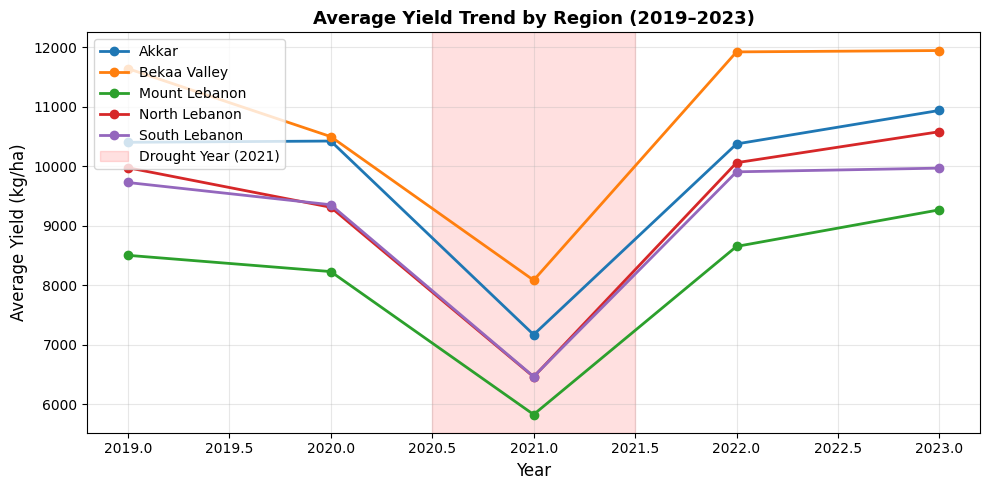

In [ ]:
# Year-over-year trend: is any region improving or declining?
trend = df.groupby(['year','region'])['yield_kg_ha'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
for col in trend.columns:
    ax.plot(trend.index, trend[col], marker='o', linewidth=2, label=col)

ax.axvspan(2020.5, 2021.5, alpha=0.12, color='red', label='Drought Year (2021)')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Yield (kg/ha)', fontsize=12)
ax.set_title('Average Yield Trend by Region (2019–2023)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### ✏️ YOUR TURN — Regional Analysis


In [ ]:
# ============================================================
# YOUR TURN: Regional Analysis
# ============================================================

# Q3: Which region would you recommend for a new agricultural investment?
#     Use the heatmap and trend chart to justify your answer.

your_answer_region = """
[YOUR ANSWER HERE]

Things to consider:
- Which region has the best overall average?
- Does performance hold up during drought years?
- Are there crops that do exceptionally well in one region vs others?
- What real-world factors (infrastructure, water access, market proximity)
  might support or challenge what the data shows?
"""

print("✅ Regional analysis answer saved.")


---
## 📈 Step 5 — What Drives Yield? Correlation Analysis

Now let's ask a more analytical question: **which factors most strongly correlate with higher yield?**

> **Important:** Correlation ≠ causation. A strong correlation tells you two variables move together — it doesn't tell you one *causes* the other.


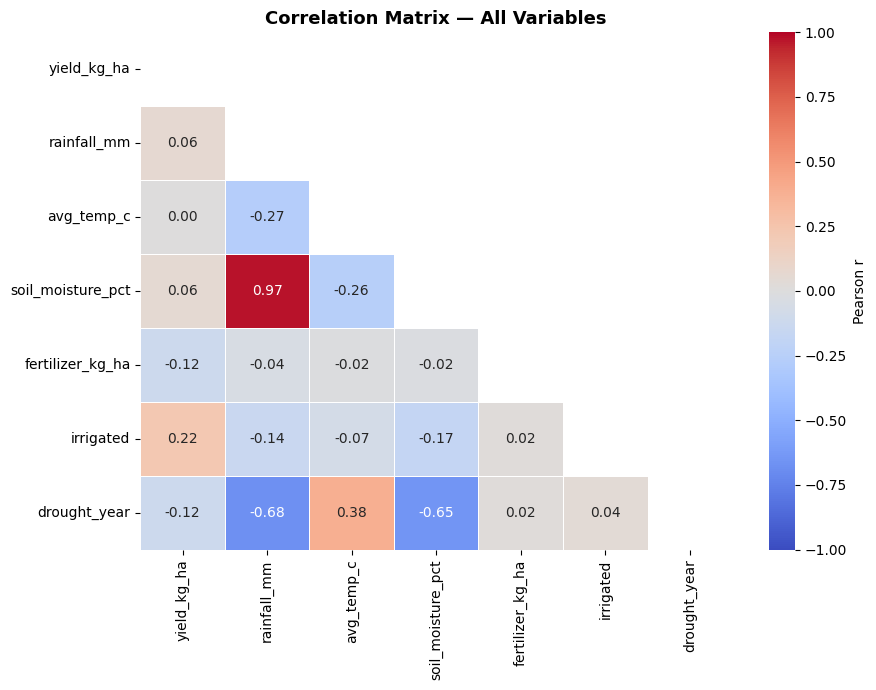

In [ ]:
# Correlation matrix of numeric features vs yield
numeric_cols = ['yield_kg_ha', 'rainfall_mm', 'avg_temp_c',
                'soil_moisture_pct', 'fertilizer_kg_ha', 'irrigated', 'drought_year']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True   # show lower triangle only

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix — All Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


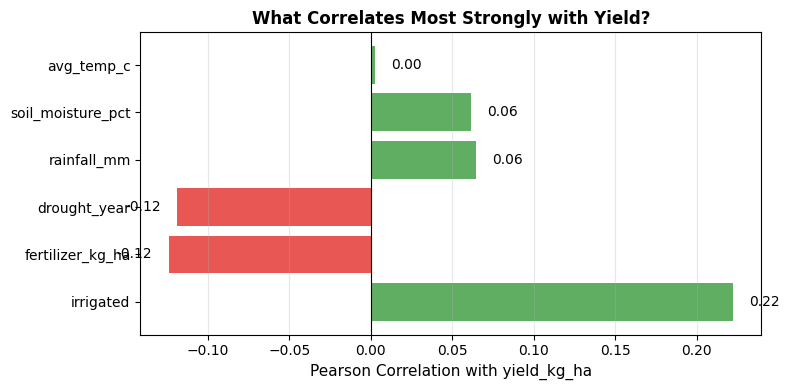


Correlation values:
irrigated            0.222
fertilizer_kg_ha    -0.124
drought_year        -0.119
rainfall_mm          0.065
soil_moisture_pct    0.061
avg_temp_c           0.003


In [ ]:
# Focus: correlation of each variable specifically with yield
yield_corr = df[numeric_cols].corr()['yield_kg_ha'].drop('yield_kg_ha').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E53935' if v < 0 else '#43A047' for v in yield_corr]
bars = ax.barh(yield_corr.index, yield_corr.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with yield_kg_ha', fontsize=11)
ax.set_title('What Correlates Most Strongly with Yield?', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, yield_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

print("\nCorrelation values:")
print(yield_corr.round(3).to_string())


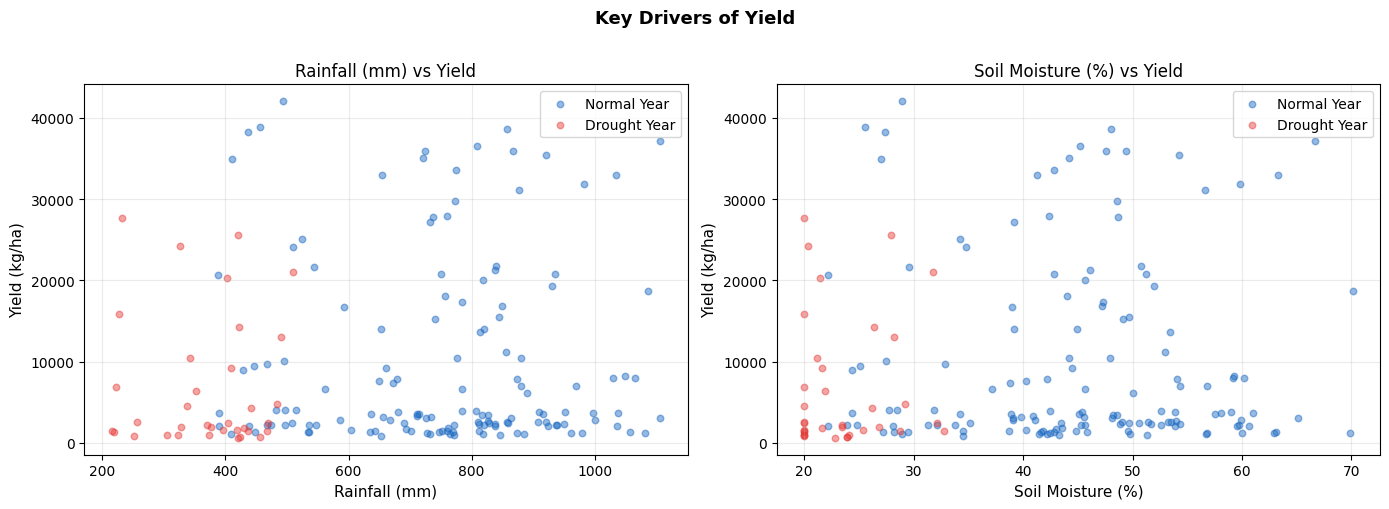

In [ ]:
# Scatter: rainfall vs yield (coloured by drought year)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes, ['rainfall_mm', 'soil_moisture_pct'],
                                 ['Rainfall (mm)', 'Soil Moisture (%)']):
    for drought, color, name in [(0, '#1565C0', 'Normal Year'), (1, '#E53935', 'Drought Year')]:
        sub = df[df.drought_year == drought]
        ax.scatter(sub[col], sub['yield_kg_ha'], alpha=0.45, s=22, color=color, label=name)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Yield (kg/ha)', fontsize=11)
    ax.set_title(f'{label} vs Yield', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.25)

plt.suptitle('Key Drivers of Yield', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 📊 Step 6 — Build Your Dashboard

Now put it all together. Create a **2×2 figure** that serves as your "Smart Crop Dashboard" — four panels that together tell a complete story about the data.

A suggested layout is given, but you are encouraged to modify it to highlight what *you* found most interesting.


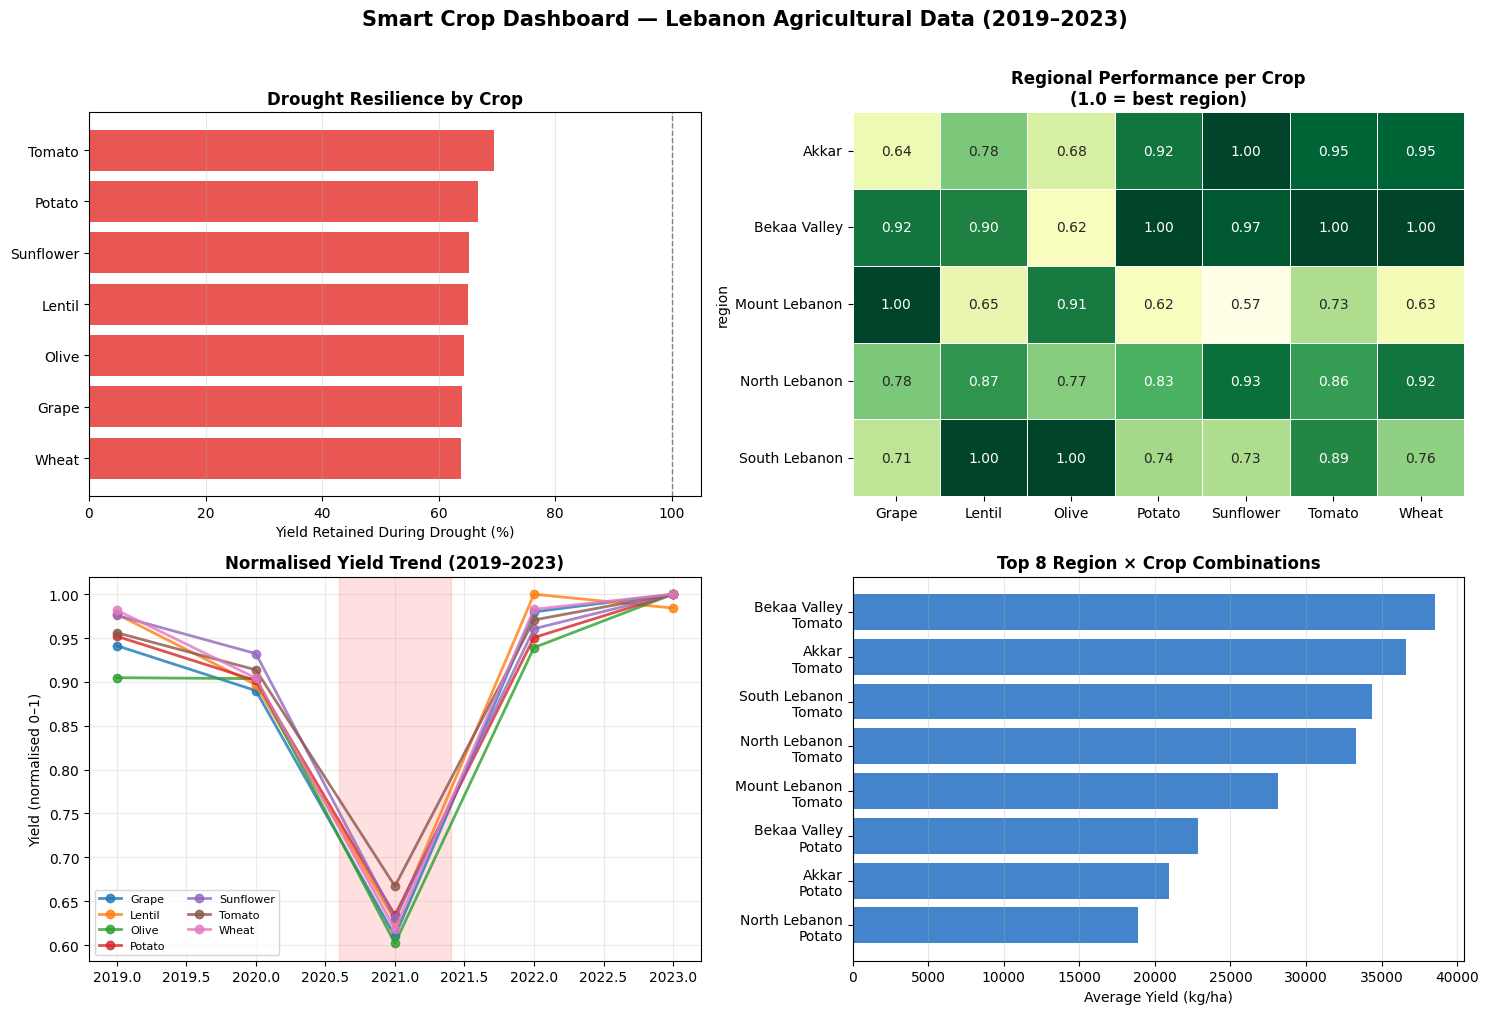


✅ Dashboard saved as 'smart_crop_dashboard.png'


In [ ]:
# ============================================================
# YOUR DASHBOARD — you can customise this freely
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Smart Crop Dashboard — Lebanon Agricultural Data (2019–2023)',
             fontsize=15, fontweight='bold', y=1.01)

# --- Panel 1: Drought resilience bar chart ---
ax1 = axes[0, 0]
res = resilience.sort_values('Yield Retained (%)')
colors_bar = ['#E53935' if v < 70 else '#FB8C00' if v < 85 else '#43A047'
              for v in res['Yield Retained (%)']]
ax1.barh(res.index, res['Yield Retained (%)'], color=colors_bar, alpha=0.85)
ax1.axvline(100, color='grey', linestyle='--', linewidth=1)
ax1.set_xlabel('Yield Retained During Drought (%)')
ax1.set_title('Drought Resilience by Crop', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# --- Panel 2: Best region per crop (heatmap) ---
ax2 = axes[0, 1]
piv = df[df.drought_year == 0].groupby(['region','crop'])['yield_kg_ha'].mean().unstack()
piv_n = piv.div(piv.max())
sns.heatmap(piv_n.round(2), annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.4, ax=ax2, cbar=False)
ax2.set_title('Regional Performance per Crop\n(1.0 = best region)', fontweight='bold')
ax2.set_xlabel('')

# --- Panel 3: Trend over time ---
ax3 = axes[1, 0]
trend_crop = df.groupby(['year','crop'])['yield_kg_ha'].mean().unstack()
trend_norm = trend_crop.div(trend_crop.max())   # normalise to compare shapes
for col in trend_norm.columns:
    ax3.plot(trend_norm.index, trend_norm[col], marker='o', linewidth=2, label=col, alpha=0.8)
ax3.axvspan(2020.6, 2021.4, alpha=0.12, color='red')
ax3.set_title('Normalised Yield Trend (2019–2023)', fontweight='bold')
ax3.set_ylabel('Yield (normalised 0–1)')
ax3.legend(fontsize=8, ncol=2)
ax3.grid(alpha=0.25)

# --- Panel 4: Top crop × region combination ---
ax4 = axes[1, 1]
combo = df[df.drought_year == 0].groupby(['region','crop'])['yield_kg_ha'].mean()
top10 = combo.sort_values(ascending=False).head(8)
top10_labels = [f"{r}\n{c}" for r,c in top10.index]
ax4.barh(top10_labels[::-1], top10.values[::-1], color='#1565C0', alpha=0.8)
ax4.set_xlabel('Average Yield (kg/ha)')
ax4.set_title('Top 8 Region × Crop Combinations', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('smart_crop_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Dashboard saved as 'smart_crop_dashboard.png'")


---
## 💾 Step 7 — Download the Dataset (Optional)

If you want to analyse the data in **Excel, Tableau, or any other tool**, run this cell to download it.


In [ ]:
# Export as Excel and CSV
try:
    df.to_excel('crop_dataset_lebanon.xlsx', index=False)
    print("✅ Excel file ready: crop_dataset_lebanon.xlsx")
except Exception:
    print("⚠️  openpyxl not available — saving as CSV instead")
    df.to_csv('crop_dataset_lebanon.csv', index=False)
    print("✅ CSV file ready: crop_dataset_lebanon.csv")

# Download in Google Colab
try:
    from google.colab import files
    try:
        files.download('crop_dataset_lebanon.xlsx')
    except Exception:
        files.download('crop_dataset_lebanon.csv')
    print("⬇️  Download started automatically")
except ImportError:
    print("ℹ️  Not running in Colab — find the file in the left sidebar under 'Files'")


---
## 📝 Graded Reflection Questions

**These are the questions you submit for grading.**

Read each question carefully. Your answers should be based on the data you explored above —
but you are also encouraged to connect your findings to real-world knowledge about Lebanese
agriculture, climate, or food systems.

> **How to submit:**
> 1. Fill in your answers in the three cells below (Q1, Q2, Q3).
> 2. Run the **Auto-Grader** cell — it checks your work and prints your score.
> 3. Run the **Generate Submission File** cell — it creates `submission_[yourname].json`.
> 4. Download that file and **upload it** to the assignment box on Karianet.


In [ ]:
# ============================================================
# GRADED QUESTION 1 — Crop Selection
# ============================================================
# Based on your analysis, which ONE crop would you recommend
# for a smallholder farmer in Lebanon who is most concerned
# about climate variability and drought risk?
#
# Your answer must:
#   (a) Name the crop
#   (b) Reference at least ONE specific finding from the data
#       (e.g. drought resilience %, yield trend, correlation)
#   (c) Mention at least ONE non-data consideration
#       (e.g. market demand, water requirements, cultural use)

graded_q1 = """
(a) Recommended crop: [CROP NAME]

(b) Data evidence:
    [Reference a specific number or chart from your analysis above]

(c) Non-data consideration:
    [Why does this crop also make sense in the real world?]
"""

print(graded_q1)


In [ ]:
# ============================================================
# GRADED QUESTION 2 — Region Selection
# ============================================================
# Which region would you target for expanding production of
# the crop you chose in Question 1?
#
# Your answer must:
#   (a) Name the region
#   (b) Reference the heatmap or trend data to support your choice
#   (c) Acknowledge one weakness or risk of that region

graded_q2 = """
(a) Recommended region: [REGION NAME]

(b) Data evidence:
    [Reference the heatmap, regional average, or trend chart]

(c) Risk or limitation:
    [What challenge might this region face? E.g. water access, altitude, infrastructure]
"""

print(graded_q2)


In [ ]:
# ============================================================
# GRADED QUESTION 3 — AI Tool Reflection
# ============================================================
# You used Python + pandas/matplotlib to analyse this data.
# A colleague suggests using an AI tool like PandasAI, Excel Copilot,
# or ChatGPT Code Interpreter instead of writing code manually.
#
# (a) What would be the main ADVANTAGE of using an AI tool here?
# (b) What would be the main RISK or limitation?
# (c) Would your conclusion about crop/region change if the AI
#     made a calculation error you didn't catch? How would you verify?

graded_q3 = """
(a) Advantage of AI tool:
    [Your answer]

(b) Risk or limitation:
    [Your answer — think about hallucinations, data privacy, error detection]

(c) Verification approach:
    [How would you check the AI's output before making a real recommendation?]
"""

print(graded_q3)


In [ ]:
# ============================================================
# 🤖 AUTO-GRADER — Run this after answering Q1, Q2, Q3
# ============================================================
import re, hashlib, json as _json, datetime

VALID_CROPS   = ['wheat','olive','potato','tomato','lentil','grape','sunflower']
VALID_REGIONS = ['bekaa valley','south lebanon','north lebanon','akkar','mount lebanon']

score   = 0
max_pts = 0
report  = []

def check(label, points, passed, feedback_ok, feedback_fail):
    global score, max_pts
    max_pts += points
    if passed:
        score += points
        report.append(f"  ✅ [{points}/{points}] {label}: {feedback_ok}")
    else:
        report.append(f"  ❌ [0/{points}] {label}: {feedback_fail}")

# ── Q1 checks ──
q1 = graded_q1.lower()
check("Q1 — Crop named", 1,
      any(c in q1 for c in VALID_CROPS),
      "Valid crop found.",
      f"No recognised crop found. Choose from: {', '.join(VALID_CROPS)}")

check("Q1 — Data evidence", 2,
      bool(re.search(r'\d+\.?\d*\s*%?', q1)) and '[reference' not in q1,
      "Contains a specific number from your analysis.",
      "Must reference at least one specific number or percentage from the data.")

check("Q1 — Non-data reasoning", 1,
      len(q1.strip()) > 200 and '[why does' not in q1,
      "Answer is detailed enough.",
      "Answer too short — add real-world context beyond the data.")

# ── Q2 checks ──
q2 = graded_q2.lower()
check("Q2 — Region named", 1,
      any(r in q2 for r in VALID_REGIONS),
      "Valid Lebanese region found.",
      f"No recognised region. Use one of: {', '.join(VALID_REGIONS)}")

check("Q2 — Data evidence", 2,
      ('[reference' not in q2) and len(q2.strip()) > 150,
      "Contains chart/heatmap reference.",
      "Must reference the heatmap, trend chart, or a specific number.")

check("Q2 — Risk/limitation acknowledged", 1,
      any(w in q2 for w in ['risk','challenge','water','limitation','weakness','drought','infra']),
      "Risk or limitation mentioned.",
      "Must mention at least one risk or weakness of the chosen region.")

# ── Q3 checks ──
q3 = graded_q3.lower()
check("Q3 — Advantage stated", 1,
      '[your answer]' not in q3 and len(q3.strip()) > 100,
      "Advantage provided.",
      "Answer the advantage section — it's still a placeholder.")

check("Q3 — Risk/hallucination addressed", 2,
      any(w in q3 for w in ['hallucin','error','bias','risk','wrong','incorrect','limitation','verify','check']),
      "Risk or verification addressed.",
      "Must address AI risks (hallucinations, errors) and how to verify output.")

# ── Dashboard check ──
import os
check("Dashboard saved", 1,
      os.path.exists('smart_crop_dashboard.png'),
      "Dashboard PNG found.",
      "Run Step 6 first to generate your dashboard.")

# ── Print report ──
pct = round(score / max_pts * 100)
print("=" * 55)
print(f"  AUTO-GRADER REPORT — {STUDENT_NAME}")
print("=" * 55)
for line in report:
    print(line)
print("-" * 55)
print(f"  TOTAL: {score}/{max_pts} pts  ({pct}%)")
if pct == 100:
    print("  🎉 All checks passed — ready to generate your submission file!")
elif pct >= 70:
    print("  📝 Good progress — fix the ❌ items above, then re-run.")
else:
    print("  ⚠️  Several items incomplete — review the ❌ feedback above.")
print("=" * 55)

# Store for export
_grade_score  = score
_grade_max    = max_pts
_grade_pct    = pct
_grade_report = report


In [ ]:
# ============================================================
# 📦 GENERATE SUBMISSION FILE — Run after auto-grader passes
# ============================================================
import json as _json, base64, datetime, hashlib, os

# Encode dashboard image if it exists
_img_b64 = ""
if os.path.exists('smart_crop_dashboard.png'):
    with open('smart_crop_dashboard.png', 'rb') as _f:
        _img_b64 = base64.b64encode(_f.read()).decode()

# Build submission payload
_submission = {
    "course":       "AI for Sustainable Development",
    "session":       "Session 3 — AI in Agriculture",
    "activity":      "Smart Crop Dashboard Activity",
    "student_name":  STUDENT_NAME,
    "student_email": STUDENT_EMAIL,
    "submitted_at":  datetime.datetime.utcnow().isoformat() + "Z",
    "auto_grade": {
        "score":   _grade_score,
        "max":     _grade_max,
        "percent": _grade_pct,
        "report":  _grade_report,
    },
    "answers": {
        "Q1_crop_selection":    graded_q1,
        "Q2_region_selection":  graded_q2,
        "Q3_ai_tool_reflection": graded_q3,
    },
    "dashboard_image_b64": _img_b64,
}

# Sign the payload (tamper-evident checksum)
_payload_str = _json.dumps({k: v for k, v in _submission.items()
                             if k != 'checksum'}, sort_keys=True)
_submission['checksum'] = hashlib.sha256(_payload_str.encode()).hexdigest()

# Write file
_safe_name = STUDENT_NAME.strip().lower().replace(' ', '_')
_filename  = f'submission_{_safe_name}.json'
with open(_filename, 'w') as _f:
    _json.dump(_submission, _f, indent=2, ensure_ascii=False)

print(f"✅ Submission file created: {_filename}")
print(f"   Student : {STUDENT_NAME} <{STUDENT_EMAIL}>")
print(f"   Score   : {_grade_score}/{_grade_max} ({_grade_pct}%)")
print(f"   Checksum: {_submission['checksum'][:16]}...")
print()

# Auto-download in Colab
try:
    from google.colab import files
    files.download(_filename)
    print("⬇️  Download started — check your Downloads folder.")
    print()
    print("📌 NEXT STEP: Go to Karianet and upload this file")
    print("   to the assignment box in Session 3 of the course.")
except ImportError:
    print("ℹ️  Not in Colab — find the file in the Files panel (left sidebar).")


In [ ]:
# ============================================================
# BONUS (Optional, not graded)
# ============================================================
# Add ONE additional analysis of your own choosing.
# Examples:
#   - Compare irrigated vs rain-fed yields for your chosen crop
#   - Plot the 5-year yield forecast using a simple linear trend
#   - Identify which region was hit HARDEST by the 2021 drought

# Your bonus analysis here:
# ...

print("Bonus analysis space — add your own code above this line.")


---
## ✅ You're Done!

**Submission checklist:**
- [ ] Your name and email were entered at the top
- [ ] All three graded questions (Q1, Q2, Q3) are filled in
- [ ] The dashboard chart was generated (Step 6)
- [ ] The Auto-Grader cell ran without ❌ errors
- [ ] You downloaded `submission_[yourname].json`
- [ ] You uploaded that file to the assignment box on Karianet

---
*Smart Crop Dashboard Activity · AI Module Course · ESDU @ AUB · Session 3*
